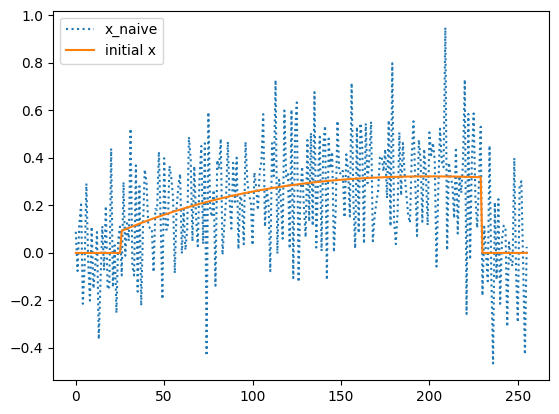

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt,sin,cos,pi,exp

N = 256
a = 0.1
b = 0.9
h = 1/N
f = lambda t: sin(t)*exp(-t) if 0.1<t<0.9 else 0

s_grid = np.array([i*h + h/2 for i in range(N)])
# print(s_grid)
t_grid = np.array([i*h for i in range(1,N+1)])

x_grid = [f(s) for s in s_grid]

# Week2, Ex3 - AbelProblem
def k(t,s):
    if s<t:
        return 1/sqrt(pi*(t-s))
    else:
        return 0

A = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        A[i,j] = h * k(t_grid[i], s_grid[j])

y_grid = A @ x_grid

SVs_A = np.linalg.svd(A,compute_uv=False)
j_decay = [j**(-1/2) for j in range(1,N)]

# plt.semilogy(SVs_A,label="SVs of A")
# plt.semilogy(j_decay,label="j_decay")
# plt.legend()
# plt.show()

np.random.seed(42)
d = np.random.randn(N)
d = d/np.linalg.norm(d) * 0.05 * np.linalg.norm(y_grid)
y_delta = y_grid + d

x_naive = np.linalg.solve(A,y_delta)
plt.plot(x_naive,label="x_naive",linestyle=":")
plt.plot(x_grid,label="initial x")
plt.legend()
plt.show()

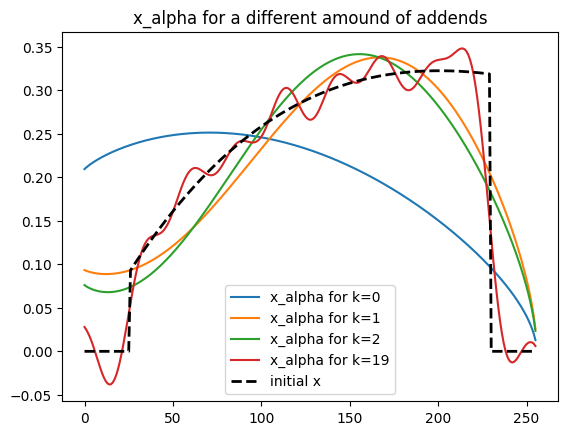

In [71]:
# TSVD solution (different truncations)
U, svA, VT = np.linalg.svd(A)

k = 20
x_alpha = 0

for i in range(k):
    yi = U[:,i]
    xi = VT.T[:,i]
    mu_i = svA[i]

    x_alpha += (y_delta @ yi) / mu_i * xi
    if i>18 or i<3:     # hier die k-werte aussuchen, die geprinted werden sollen
        plt.plot(x_alpha,label=f"x_alpha for k={i}")

plt.plot(x_grid,label="initial x",lw=2,color='black',linestyle='--')
plt.title("x_alpha for a different amound of addends")
plt.legend()
plt.show()